# Condition 04 - AM + Island Migration: Equilibrium & Identifiability

This notebook runs the two condition-04 test procedures on small, laptop-sized
simulations and presents the results.

- **Parts 1-2 (equilibrium):** do the phenotypic variances settle by the final
  generation, or keep inflating? Which parameter ranges stay stable?
- **Parts 3-4 (identifiability):** which parameters can be estimated from PGS
  correlations, and which should be fixed? move_p is kept as a free target.

Run the cells top to bottom. All sizes are small for speed; raise them in the
config cells for sharper results.

## Setup

In [11]:
import sys
import importlib
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# make the sibling modules importable (this notebook lives beside them)
NB_DIR = Path.cwd()
if str(NB_DIR) not in sys.path:
    sys.path.insert(0, str(NB_DIR))

import condition4_common as c4
import test_equilibrium as teq
import test_identifiability as tid
# pick up any edits to the modules without restarting the kernel
importlib.reload(c4); importlib.reload(teq); importlib.reload(tid)

plt.rcParams["figure.figsize"] = (8, 4)
pd.set_option("display.width", 140)
print("Baseline parameters:")
pd.Series(c4.BASELINE_PARAMS)

Baseline parameters:


vg1                0.450
prop_h2_latent1    0.600
prop_h2_latent2    1.000
vg2                0.500
f11                0.100
f22                0.175
re                 0.250
am11               0.500
rg                 0.305
move_p             0.155
dtype: float64

## 1. Variance trajectories

Phenotypic variance per generation for a few settings. Trait 1 = EA (mating
trait); Trait 2 = migration (latent, drives migration). A flat tail = at
equilibrium; a rising tail = still inflating.

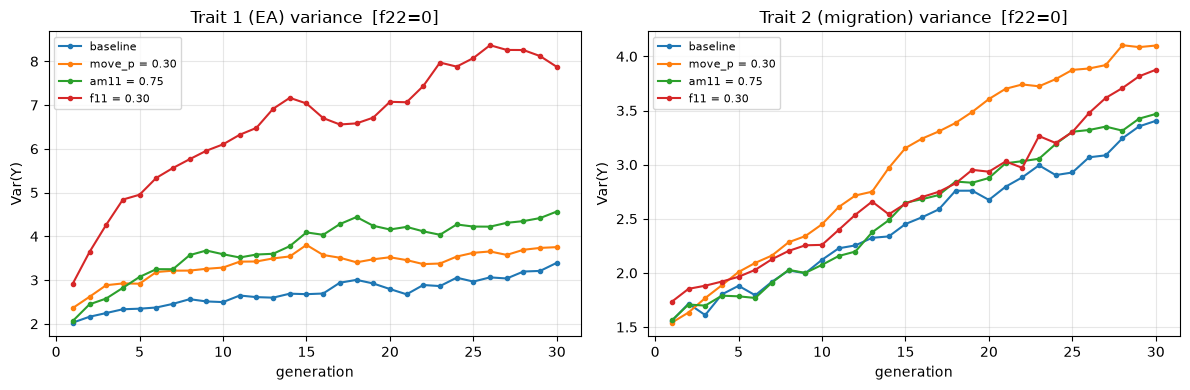

In [12]:
# f22 is held at 0 for the equilibrium check (per request)
FIX = {"f22": 0.0}
demo = {
    "baseline":       {},
    "move_p = 0.30":  {"move_p": 0.30},
    "am11 = 0.75":    {"am11": 0.75},
    "f11 = 0.30":     {"f11": 0.30},
}
POP, NCV, GENS = 3000, 200, 30

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for label, ov in demo.items():
    r = c4.run_island_simulation(c4.make_full_params({**FIX, **ov}), pop_size=POP,
                                 n_generations=GENS, n_islands=5, n_cv=NCV,
                                 seed=2024, save_history=False)
    t = c4.variance_trajectory(r)
    axes[0].plot(t["gen"], t["var_Y1"], marker="o", ms=3, label=label)
    axes[1].plot(t["gen"], t["var_Y2"], marker="o", ms=3, label=label)
axes[0].set_title("Trait 1 (EA) variance  [f22=0]")
axes[1].set_title("Trait 2 (migration) variance  [f22=0]")
for ax in axes:
    ax.set_xlabel("generation"); ax.set_ylabel("Var(Y)")
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 2. Equilibrium parameter sweep

Each parameter is swept across its range (others at baseline), with **`f22` fixed
at 0**. **Every reported number is the average of `n_iter = 10` independent
simulations** (different seeds), so the statistics are not single-run cases. For
each condition we report the variance of both traits over the **last three
generations** and a verdict (**equilibrium** vs **still changing**), plus the PGS
and phenotypic correlations across relationship types — 1st and 2nd degree
(`S, P, PP, PS`) and the distant in-law chains 5th degree (`MSMSM, MSMSC`) and
6th degree (`SMSMSC, MSMSMS`) — in two separate tables below. `move_p` is kept free.

In [12]:
# Each condition is the AVERAGE of n_iter=10 independent simulations (not a single
# run). Averaging already suppresses Monte-Carlo noise, so a smaller per-run
# population keeps the 10x cost laptop-friendly; raise pop_size / n_iter for more precision.
eq_args = SimpleNamespace(
    pop_size=1000, n_generations=30, n_islands=5, n_cv=100, seed=12345,
    grid=5, cap=3.0, drift_tol=0.05, big=15.0, collapse=0.2, n_random=5,
    min_pairs=25, n_iter=10, fixed={"f22": 0.0},
    params=["am11", "f11", "vg2", "re", "rg", "move_p"],
)
sweep_df = teq.sweep(eq_args)
# Variance of both traits over the last three generations (avg of 10 iters) + verdict
teq.variance_table(sweep_df).round(3)


--- sweeping am11 over [0.250, 0.750] (5 points) ---
  am11=0.250  ->  still changing (Y1 last3=2.38/2.38/2.42 | Y2 last3=3.07/3.21/3.20)
  am11=0.375  ->  equilibrium    (Y1 last3=2.66/2.65/2.69 | Y2 last3=3.09/3.20/3.20)
  am11=0.500  ->  still changing (Y1 last3=2.92/2.93/2.97 | Y2 last3=3.00/3.12/3.16)
  am11=0.625  ->  equilibrium    (Y1 last3=3.30/3.26/3.34 | Y2 last3=3.10/3.16/3.18)
  am11=0.750  ->  equilibrium    (Y1 last3=3.88/3.83/3.90 | Y2 last3=3.29/3.35/3.44)

--- sweeping f11 over [0.050, 0.300] (5 points) ---
  f11=0.050  ->  equilibrium    (Y1 last3=2.48/2.51/2.52 | Y2 last3=3.18/3.25/3.29)
  f11=0.113  ->  equilibrium    (Y1 last3=3.13/3.19/3.19 | Y2 last3=3.02/3.12/3.16)
  f11=0.175  ->  equilibrium    (Y1 last3=3.94/3.90/4.03 | Y2 last3=3.09/3.13/3.22)
  f11=0.237  ->  still changing (Y1 last3=4.91/4.82/5.02 | Y2 last3=2.98/3.08/3.09)
  f11=0.300  ->  still changing (Y1 last3=7.26/7.23/7.33 | Y2 last3=3.22/3.32/3.36)

--- sweeping vg2 over [0.100, 0.900] (5 points)

,param,value,Y1[-3],Y1[-2],Y1[-1],Y2[-3],Y2[-2],Y2[-1],status,verdict
0,am11,0.250,2.382,2.384,2.425,3.066,3.206,3.197,drifting,still changing
1,am11,0.375,2.659,2.646,2.691,3.090,3.197,3.197,equilibrium,equilibrium
2,am11,0.500,2.919,2.928,2.971,3.000,3.124,3.162,drifting,still changing
3,am11,0.625,3.298,3.262,3.341,3.096,3.162,3.175,equilibrium,equilibrium
4,am11,0.750,3.882,3.831,3.901,3.290,3.346,3.444,equilibrium,equilibrium
5,f11,0.050,2.484,2.512,2.524,3.176,3.248,3.286,equilibrium,equilibrium
6,f11,0.112,3.127,3.186,3.191,3.021,3.120,3.155,equilibrium,equilibrium
7,f11,0.175,3.935,3.905,4.032,3.085,3.128,3.219,equilibrium,equilibrium
8,f11,0.238,4.905,4.816,5.023,2.984,3.081,3.092,drifting,still changing
9,f11,0.300,7.258,7.229,7.328,3.220,3.324,3.365,drifting,still changing


In [13]:
# PGS (trait-1 EA polygenic score) correlations by relationship type
# 1st: S=siblings, P=parent-offspring | 2nd: PP=grandparent, PS=avuncular
# 5th: MSMSM, MSMSC | 6th: SMSMSC, MSMSMS  (distant in-law chains)
teq.pgs_corr_table(sweep_df).round(3)

,param,value,S,P,PP,PS,MSMSM,MSMSC,SMSMSC,MSMSMS
0,am11,0.250,0.549,0.557,0.320,0.320,0.056,0.063,0.056,0.057
1,am11,0.375,0.586,0.590,0.372,0.368,0.071,0.082,0.086,0.065
2,am11,0.500,0.594,0.601,0.379,0.366,0.050,0.060,0.063,0.043
3,am11,0.625,0.621,0.629,0.420,0.418,0.075,0.084,0.083,0.071
4,am11,0.750,0.664,0.672,0.476,0.469,0.118,0.133,0.119,0.105
5,f11,0.050,0.591,0.594,0.370,0.367,0.058,0.065,0.055,0.047
6,f11,0.112,0.623,0.625,0.416,0.408,0.091,0.111,0.102,0.072
7,f11,0.175,0.612,0.618,0.410,0.404,0.078,0.084,0.082,0.063
8,f11,0.238,0.613,0.616,0.402,0.397,0.078,0.078,0.087,0.080
9,f11,0.300,0.607,0.607,0.392,0.389,0.063,0.066,0.074,0.047


In [14]:
# Phenotypic (Y1) correlations by relationship type
# 1st: S=siblings, P=parent-offspring | 2nd: PP=grandparent, PS=avuncular
# 5th: MSMSM, MSMSC | 6th: SMSMSC, MSMSMS  (distant in-law chains)
teq.pheno_corr_table(sweep_df).round(3)

,param,value,S,P,PP,PS,MSMSM,MSMSC,SMSMSC,MSMSMS
0,am11,0.250,0.543,0.564,0.379,0.373,0.122,0.135,0.133,0.114
1,am11,0.375,0.594,0.616,0.426,0.424,0.144,0.150,0.151,0.126
2,am11,0.500,0.629,0.656,0.475,0.470,0.138,0.156,0.148,0.129
3,am11,0.625,0.666,0.703,0.538,0.519,0.173,0.189,0.155,0.145
4,am11,0.750,0.718,0.751,0.600,0.583,0.230,0.247,0.211,0.196
5,f11,0.050,0.565,0.607,0.442,0.411,0.128,0.128,0.110,0.106
6,f11,0.112,0.655,0.674,0.499,0.496,0.180,0.192,0.167,0.154
7,f11,0.175,0.717,0.720,0.540,0.551,0.179,0.195,0.175,0.162
8,f11,0.238,0.776,0.756,0.578,0.596,0.194,0.202,0.192,0.179
9,f11,0.300,0.847,0.797,0.636,0.679,0.233,0.252,0.251,0.211


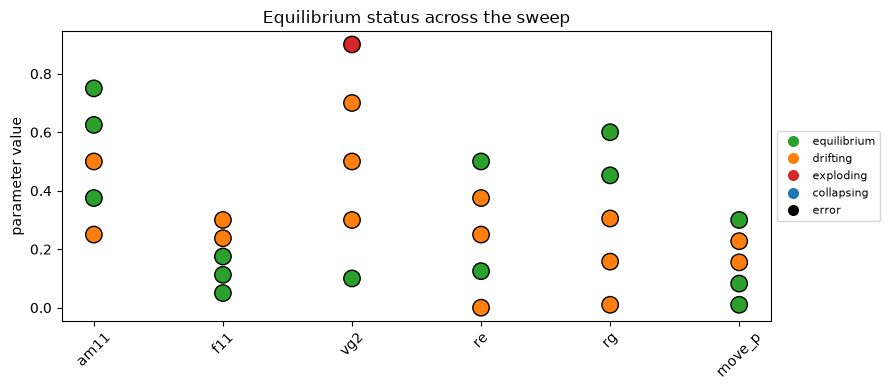

In [6]:
status_colors = {"equilibrium": "tab:green", "drifting": "tab:orange",
                 "exploding": "tab:red", "collapsing": "tab:blue", "error": "black"}
from matplotlib.lines import Line2D
params = eq_args.params
fig, ax = plt.subplots(figsize=(9, 4))
for i, p in enumerate(params):
    sub = sweep_df[sweep_df.swept_param == p]
    ax.scatter([i] * len(sub), sub["value"],
               c=[status_colors.get(s, "gray") for s in sub["status"]], s=140, edgecolor="k")
ax.set_xticks(range(len(params))); ax.set_xticklabels(params, rotation=45)
ax.set_ylabel("parameter value"); ax.set_title("Equilibrium status across the sweep")
handles = [Line2D([0], [0], marker="o", color="w", markerfacecolor=c, label=s, markersize=9)
           for s, c in status_colors.items()]
ax.legend(handles=handles, fontsize=8, loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.tight_layout(); plt.show()

## 3. Identifiability — the sensitivity Jacobian

**The question.** The simulator is a (stochastic) map from parameters to summary statistics

$$\mathbf{f}(\boldsymbol\theta)\in\mathbb{R}^{m},\qquad \boldsymbol\theta\in\mathbb{R}^{p},$$

where $\boldsymbol\theta=$ (`vg2, f11, re, am11, rg, move_p`) are the parameters we want to estimate (`f22` is held fixed at 0, matching the equilibrium setup) and $\mathbf{f}$ is the vector of PGS correlations across relationship types. Estimating $\boldsymbol\theta$ from an *observed* correlation vector $\mathbf{f}^{\mathrm{obs}}$ is only possible if different parameter values produce **distinguishable** correlation patterns. That property is **identifiability**.

**Local linearisation.** Around a baseline $\boldsymbol\theta_0$ (the midpoint of each range) a first-order Taylor expansion gives

$$\mathbf{f}(\boldsymbol\theta)\;\approx\;\mathbf{f}(\boldsymbol\theta_0)+\mathbf{J}\,(\boldsymbol\theta-\boldsymbol\theta_0),\qquad \mathbf{J}_{ij}=\frac{\partial f_i}{\partial \theta_j}.$$

$\mathbf{J}$ is the $m\times p$ **Jacobian**: column $j$ is the direction in which the correlation vector moves when parameter $j$ is nudged. Locally, recovering $\boldsymbol\theta$ from $\mathbf{f}$ is possible **iff** $\mathbf{J}$ has full column rank $p$. A near-zero column means "this parameter leaves no fingerprint on the correlations" and cannot be identified.

**Estimating $\mathbf{J}$ with common random numbers.** The simulator has no analytic derivative, so each column is a symmetric finite difference:

$$\mathbf{J}_{\cdot j}\;\approx\;\frac{\mathbf{f}(\boldsymbol\theta_0+h_j\,\mathbf{e}_j)-\mathbf{f}(\boldsymbol\theta_0-h_j\,\mathbf{e}_j)}{2h_j},\qquad h_j=\tfrac{1}{2}\,\texttt{perturb}\times\mathrm{range}_j.$$

Two tricks make this trustworthy:

- **Full-range scaling** — we report $\mathbf{J}_{\cdot j}\times\mathrm{range}_j$, i.e. the change in each correlation across the *entire plausible range* of the parameter, so columns with different scales are comparable.
- **Common random numbers** — the $+$ and $-$ runs use the **same seed**, so the same causal variants, founders and mating draws are reused. The Monte-Carlo noise then cancels in the difference and isolates the parameter's effect (a standard variance-reduction technique for simulation-based derivatives).

**Reading identifiability off $\mathbf{J}$.** We summarise the columns three ways:

1. **Per-parameter sensitivity** — the column norm $\lVert\mathbf{J}_{\cdot j}\rVert$ (reported relative to the largest). Tiny $\Rightarrow$ the parameter barely moves the data $\Rightarrow$ weakly identified $\Rightarrow$ a candidate to *fix*.
2. **Collinearity** — the cosine between two effect columns, $\dfrac{\mathbf{J}_{\cdot i}^{\top}\mathbf{J}_{\cdot j}}{\lVert\mathbf{J}_{\cdot i}\rVert\,\lVert\mathbf{J}_{\cdot j}\rVert}$. If $|\cos|\approx 1$ the two parameters move the correlations along the **same** direction, so only their combination is identified, not each separately (a *confounded pair*) — fix one of them.
3. **SVD / conditioning** — factor $\mathbf{J}=\mathbf{U}\,\boldsymbol\Sigma\,\mathbf{V}^{\top}$ with singular values $\sigma_1\ge\cdots\ge\sigma_p$. The **condition number** $\kappa=\sigma_1/\sigma_p$ measures how close $\mathbf{J}$ is to rank-deficient (small $\kappa$ = well-posed). The right-singular vector $\mathbf{v}_p$ of the smallest $\sigma_p$ is the **least-identified parameter combination**: moving $\boldsymbol\theta$ along $\mathbf{v}_p$ changes the correlations the least.

**Why this equals estimation uncertainty (Fisher information).** If the observed correlations carry roughly independent noise of variance $\sigma_\varepsilon^2$, the Fisher information for $\boldsymbol\theta$ is $\mathbf{I}=\mathbf{J}^{\top}\mathbf{J}/\sigma_\varepsilon^2$, and the Cramér–Rao bound lower-bounds the best-case estimator covariance:

$$\operatorname{Cov}(\hat{\boldsymbol\theta})\;\succeq\;\sigma_\varepsilon^{2}\,(\mathbf{J}^{\top}\mathbf{J})^{-1}.$$

Because the eigenvalues of $\mathbf{J}^{\top}\mathbf{J}$ are the $\sigma_k^{2}$, a **small singular value blows up the variance** ($\propto 1/\sigma_k^{2}$) along that parameter direction. The same SVD that flags weak or confounded parameters therefore also quantifies *how* uncertain each direction is — which is exactly why the Jacobian lets us "check identifiability this way."

Section&nbsp;4 then confirms the local picture **globally**: we sample many $\boldsymbol\theta$, simulate, and measure how well each parameter can actually be regressed back from the correlations (cross-validated $R^2$).


[Jacobian] iteration 1/10 (seed=777)
    d/d vg2    : ||effect|| = 0.2652
    d/d f11    : ||effect|| = 0.3890
    d/d re     : ||effect|| = 0.4838
    d/d am11   : ||effect|| = 0.5526
    d/d rg     : ||effect|| = 0.1840
    d/d move_p : ||effect|| = 0.3364

[Jacobian] iteration 2/10 (seed=790)
    d/d vg2    : ||effect|| = 1.1123
    d/d f11    : ||effect|| = 0.3183
    d/d re     : ||effect|| = 0.4230
    d/d am11   : ||effect|| = 0.5539
    d/d rg     : ||effect|| = 0.3237
    d/d move_p : ||effect|| = 0.5138

[Jacobian] iteration 3/10 (seed=803)
    d/d vg2    : ||effect|| = 0.9345
    d/d f11    : ||effect|| = 0.6252
    d/d re     : ||effect|| = 0.2851
    d/d am11   : ||effect|| = 1.8037
    d/d rg     : ||effect|| = 1.4848
    d/d move_p : ||effect|| = 0.3075

[Jacobian] iteration 4/10 (seed=816)
    d/d vg2    : ||effect|| = 0.3901
    d/d f11    : ||effect|| = 0.4087
    d/d re     : ||effect|| = 0.3464
    d/d am11   : ||effect|| = 0.5193
    d/d rg     : ||effect|| = 0.50

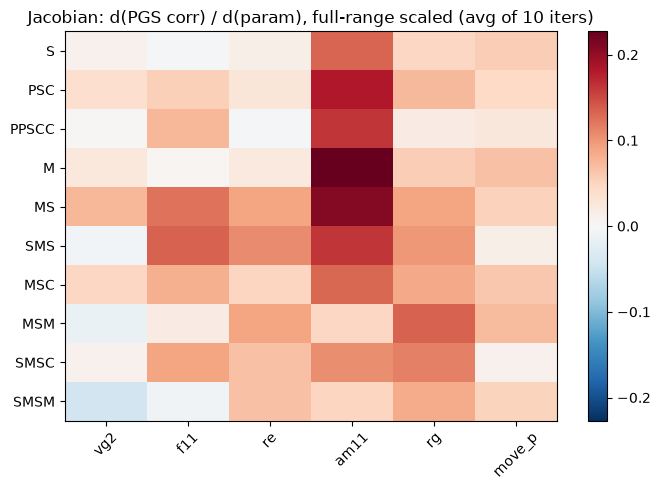

,vg2,f11,re,am11,rg,move_p
S,0.010,-0.005,0.013,0.132,0.047,0.055
PSC,0.038,0.054,0.028,0.181,0.073,0.045
PPSCC,0.003,0.075,-0.003,0.162,0.019,0.026
M,0.023,0.004,0.023,0.227,0.056,0.066
MS,0.075,0.123,0.089,0.209,0.090,0.052
SMS,-0.007,0.133,0.107,0.162,0.099,0.014
MSC,0.048,0.080,0.049,0.131,0.086,0.061
MSM,-0.014,0.019,0.090,0.048,0.133,0.072
SMSC,0.010,0.090,0.066,0.105,0.115,0.009
SMSM,-0.044,-0.007,0.067,0.049,0.085,0.051


In [7]:
# n_iter=10 -> the Jacobian is the average of 10 independent finite-difference
# estimates, and each recovery sample averages 10 simulations (not single runs).
id_args = SimpleNamespace(
    pop_size=1000, n_generations=15, n_islands=5, n_cv=150, seed=777,
    min_pairs=25, perturb=0.30, n_iter=10, weak_frac=0.15, confound_thresh=0.90,
    n_samples=25, ridge_alpha=1.0, r2_floor=0.30,
)
S = tid.build_jacobian(id_args)

vmax = np.abs(S.values).max()
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(S.values, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
ax.set_xticks(range(S.shape[1])); ax.set_xticklabels(S.columns, rotation=45)
ax.set_yticks(range(S.shape[0])); ax.set_yticklabels(S.index)
ax.set_title("Jacobian: d(PGS corr) / d(param), full-range scaled (avg of 10 iters)")
fig.colorbar(im, ax=ax); plt.tight_layout(); plt.show()
S.round(3)

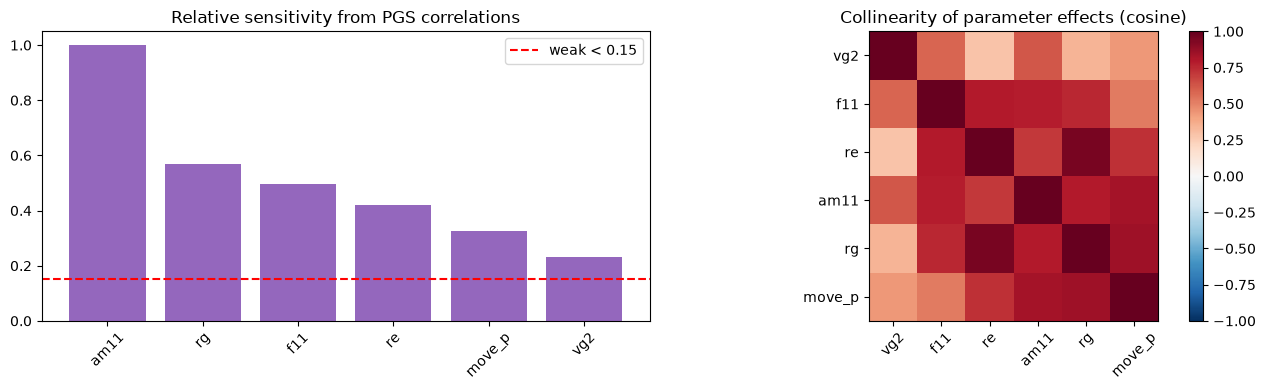

In [8]:
col_norm = np.linalg.norm(S.values, axis=0)
rel = col_norm / col_norm.max()
order = np.argsort(rel)[::-1]

Mn = S.values / np.where(col_norm > 0, col_norm, 1.0)
C = Mn.T @ Mn

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(np.array(S.columns)[order], rel[order], color="tab:purple")
axes[0].axhline(id_args.weak_frac, color="r", ls="--", label=f"weak < {id_args.weak_frac}")
axes[0].set_title("Relative sensitivity from PGS correlations")
axes[0].tick_params(axis="x", rotation=45); axes[0].legend()

im = axes[1].imshow(C, cmap="RdBu_r", vmin=-1, vmax=1)
axes[1].set_xticks(range(len(S.columns))); axes[1].set_xticklabels(S.columns, rotation=45)
axes[1].set_yticks(range(len(S.columns))); axes[1].set_yticklabels(S.columns)
axes[1].set_title("Collinearity of parameter effects (cosine)")
fig.colorbar(im, ax=axes[1]); plt.tight_layout(); plt.show()

## 4. Identifiability - recovery R2 and recommendations

Cross-validated ridge recovery of each parameter from the PGS correlations. Low
or negative R2 means the parameter is hard to estimate. The printed
recommendations combine sensitivity, collinearity, and recovery.


JACOBIAN ANALYSIS (PGS-correlation sensitivity)
  Features used: 10  (S, PSC, PPSCC, M, MS, SMS, MSC, MSM, SMSC, SMSM)

  Per-parameter sensitivity (higher = better identified from PGS corr):
    am11    : 1.000
    rg      : 0.569
    f11     : 0.495
    re      : 0.418
    move_p  : 0.327
    vg2     : 0.231

  Confounded parameter pairs (|cosine of effect directions| > 0.9):
    re       ~ rg        cos=+0.949

  Condition number of S: 17.8  (well-conditioned)
  Least-identified parameter combination (smallest singular vector):
    move_p  : +0.773
    f11     : +0.433
    rg      : -0.302
    vg2     : -0.277
    am11    : -0.163
    re      : -0.141

RECOVERY R^2  (25 sampled conditions)
    simulated 10/25
    simulated 20/25

  Using 10 features, 25 samples, 5-fold CV:
    vg2     : R^2 = -1.080  <-- poorly identified
    f11     : R^2 = -0.389  <-- poorly identified
    re      : R^2 = -0.267  <-- poorly identified
    am11    : R^2 = +0.560
    rg      : R^2 = -3.000  <-- poo

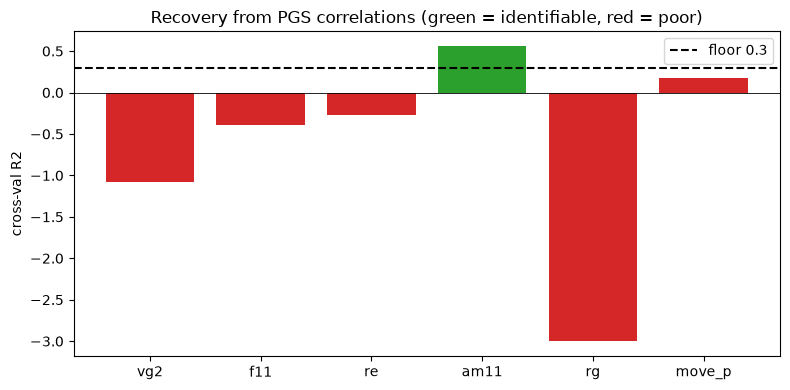

In [9]:
sens, collin = tid.analyze_jacobian(S, id_args)
rec = tid.recovery(id_args)

if rec is not None:
    vals = rec["recovery_r2"].reindex(tid.TARGETS)
    colors = ["tab:green" if v >= id_args.r2_floor else "tab:red" for v in vals.values]
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(vals.index, vals.values, color=colors)
    ax.axhline(id_args.r2_floor, color="k", ls="--", label=f"floor {id_args.r2_floor}")
    ax.axhline(0, color="k", lw=0.6)
    ax.set_ylabel("cross-val R2")
    ax.set_title("Recovery from PGS correlations (green = identifiable, red = poor)")
    ax.legend(); plt.tight_layout(); plt.show()

In [10]:
tid.recommend(sens, collin, rec, id_args)


RECOMMENDATIONS
  Consider FIXING (weak sensitivity and/or low recovery R^2):
    f11, re, rg, vg2
  Confounded pairs -- fix ONE member of each to break the tie:
    re <-> rg

  move_p (target to keep estimable):
    relative sensitivity = 0.327, recovery R^2 = +0.181
    move_p is not strongly confounded with another parameter here.


## How to act on these results

- **Equilibrium:** narrow or fix any parameter whose upper range is labelled
  exploding/drifting (keep move_p free - just cap its range if needed). Raise
  eq_args.n_generations to 30-40 to give the migration trait time to plateau.
- **Identifiability:** fix parameters with weak sensitivity or low/negative
  recovery R2; for a confounded pair, fix one member. Use id_args.n_samples >= 100
  for trustworthy recovery R2 (small samples give noisy negatives).